In [33]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


In [26]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
data = pd.read_csv(url, parse_dates=['Date'], index_col='Date')

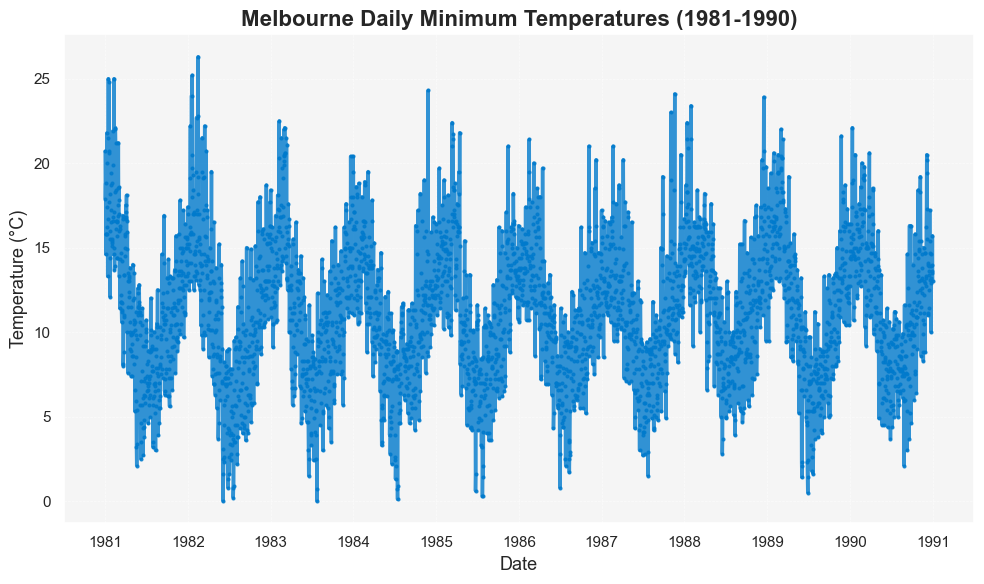

In [27]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10,6))
plt.plot(data['Temp'], color='#007acc', linewidth=2.5, linestyle='-', marker='o', markersize=2, alpha=0.8)
ax = plt.gca()
ax.set_facecolor("#f5f5f5")
plt.title('Melbourne Daily Minimum Temperatures (1981-1990)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=13)
plt.ylabel('Temperature (°C)', fontsize=13)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

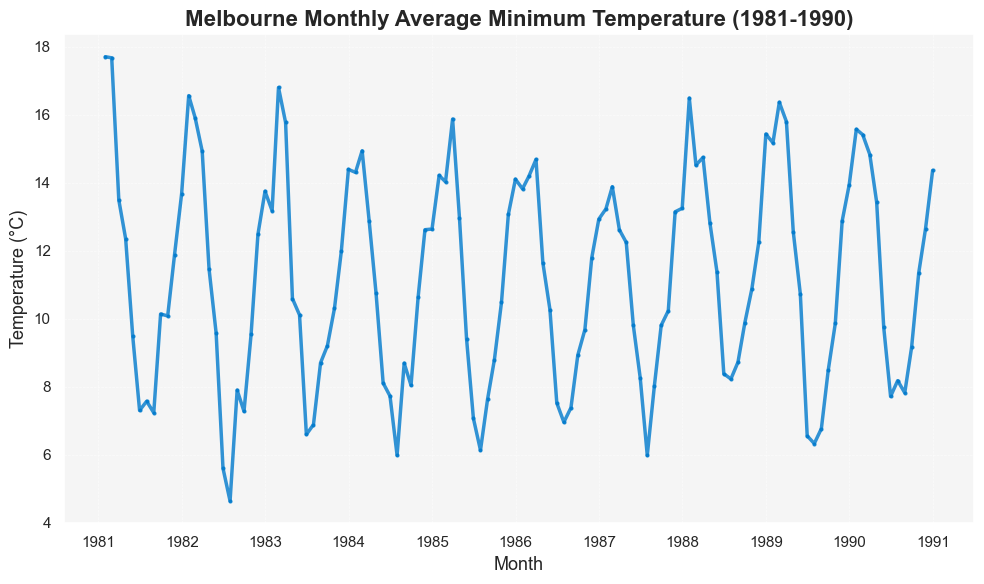

In [28]:
monthly_Avg = data['Temp'].resample('ME').mean()

sns.set_theme(style="darkgrid")
plt.figure(figsize=(10,6))
plt.plot(monthly_Avg, color='#007acc', linewidth=2.5, linestyle='-', marker='o', markersize=2, alpha=0.8)
ax = plt.gca()
ax.set_facecolor("#f5f5f5")
plt.title('Melbourne Monthly Average Minimum Temperature (1981-1990)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=13)
plt.ylabel('Temperature (°C)', fontsize=13)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

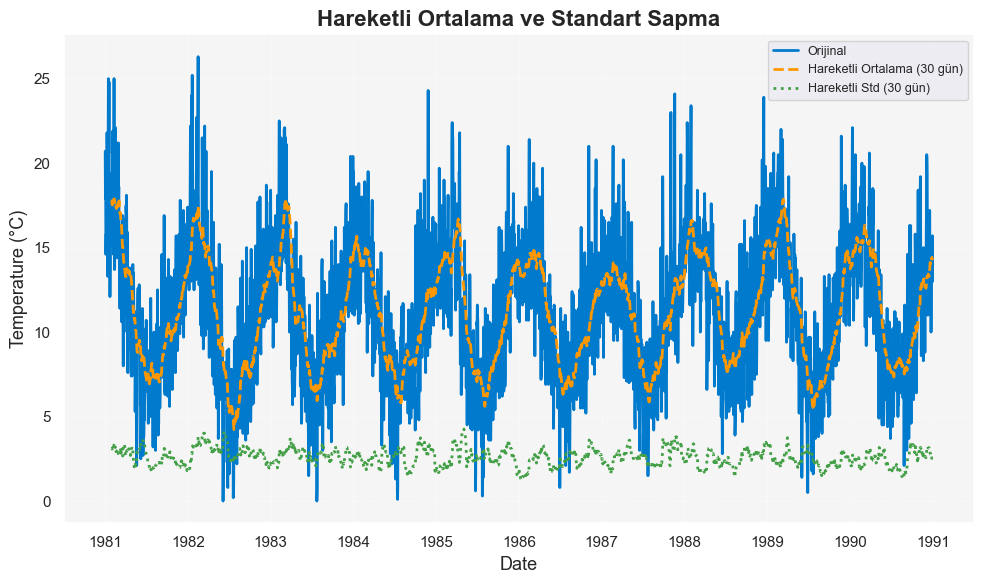

In [29]:
sns.set_theme(style="darkgrid")
colors = ['#007acc', '#ff9800', '#43a047']   

rolling_mean = data['Temp'].rolling(window=30).mean()
rolling_std = data['Temp'].rolling(window=30).std()

plt.figure(figsize=(10,6))
plt.plot(data['Temp'], color=colors[0], label='Orijinal', linewidth=2)
plt.plot(rolling_mean, color=colors[1], label='Hareketli Ortalama (30 gün)', linewidth=2, linestyle='--')
plt.plot(rolling_std, color=colors[2], label='Hareketli Std (30 gün)', linewidth=2, linestyle=':')
ax = plt.gca()
ax.set_facecolor("#f5f5f5")
plt.title('Hareketli Ortalama ve Standart Sapma', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=13)
plt.ylabel('Temperature (°C)', fontsize=13)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

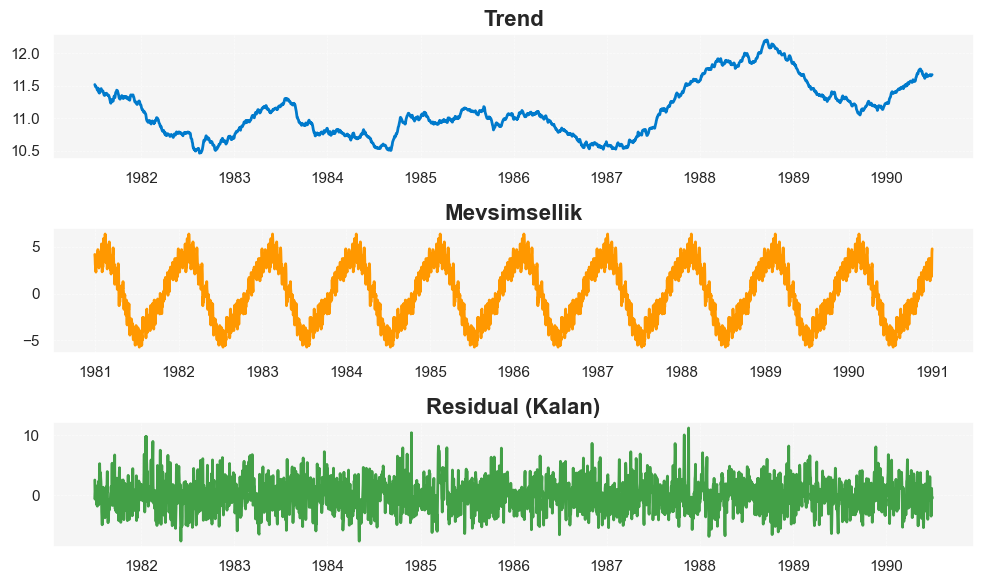

In [30]:
sns.set_theme(style="darkgrid")
colors = ['#007acc', '#ff9800', '#43a047']   

plt.figure(figsize=(10, 6))

plt.subplot(311)
plt.plot(trend, color=colors[0], linewidth=2)
ax = plt.gca()
ax.set_facecolor("#f5f5f5")
plt.title('Trend', fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.subplot(312)
plt.plot(seasonal, color=colors[1], linewidth=2)
ax = plt.gca()
ax.set_facecolor("#f5f5f5")
plt.title('Mevsimsellik', fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.subplot(313)
plt.plot(residual, color=colors[2], linewidth=2)
ax = plt.gca()
ax.set_facecolor("#f5f5f5")
plt.title('Residual (Kalan)', fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

In [31]:
def create_adf_table(series):
    result = adfuller(series)
     
    adf_results = {
        'Metrik': ['ADF Test İstatistiği', 'p-değeri', 'Kritik Değer (1%)', 
                   'Kritik Değer (5%)', 'Kritik Değer (10%)'],
        'Değer': [result[0], result[1], result[4]['1%'], 
                 result[4]['5%'], result[4]['10%']]
    }
     
    df_results = pd.DataFrame(adf_results)
    df_results.set_index('Metrik', inplace=True)
    
    pd.set_option('display.float_format', lambda x: '%.4f' % x)
    
    return df_results
 
adf_table = create_adf_table(data['Temp'])
display(adf_table)

,Değer
Metrik,
ADF Test İstatistiği,-4.4448
p-değeri,0.0002
Kritik Değer (1%),-3.4322
Kritik Değer (5%),-2.8623
Kritik Değer (10%),-2.5672


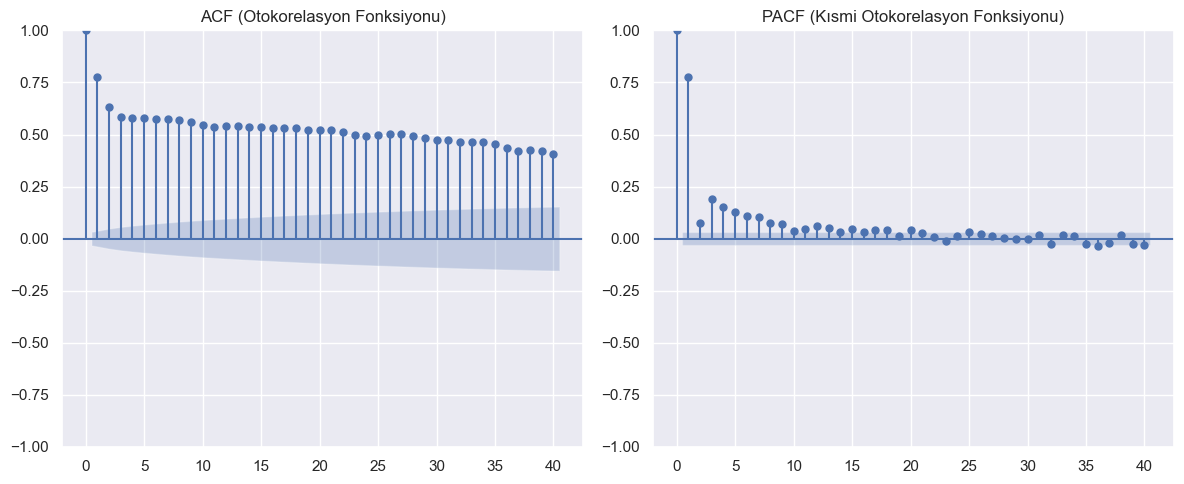

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plot_acf(data['Temp'], lags=40, ax=plt.gca())
plt.title("ACF (Otokorelasyon Fonksiyonu)")

plt.subplot(1, 2, 2)
plot_pacf(data['Temp'], lags=40, ax=plt.gca(), method='ywm')
plt.title("PACF (Kısmi Otokorelasyon Fonksiyonu)")

plt.tight_layout()
plt.show()


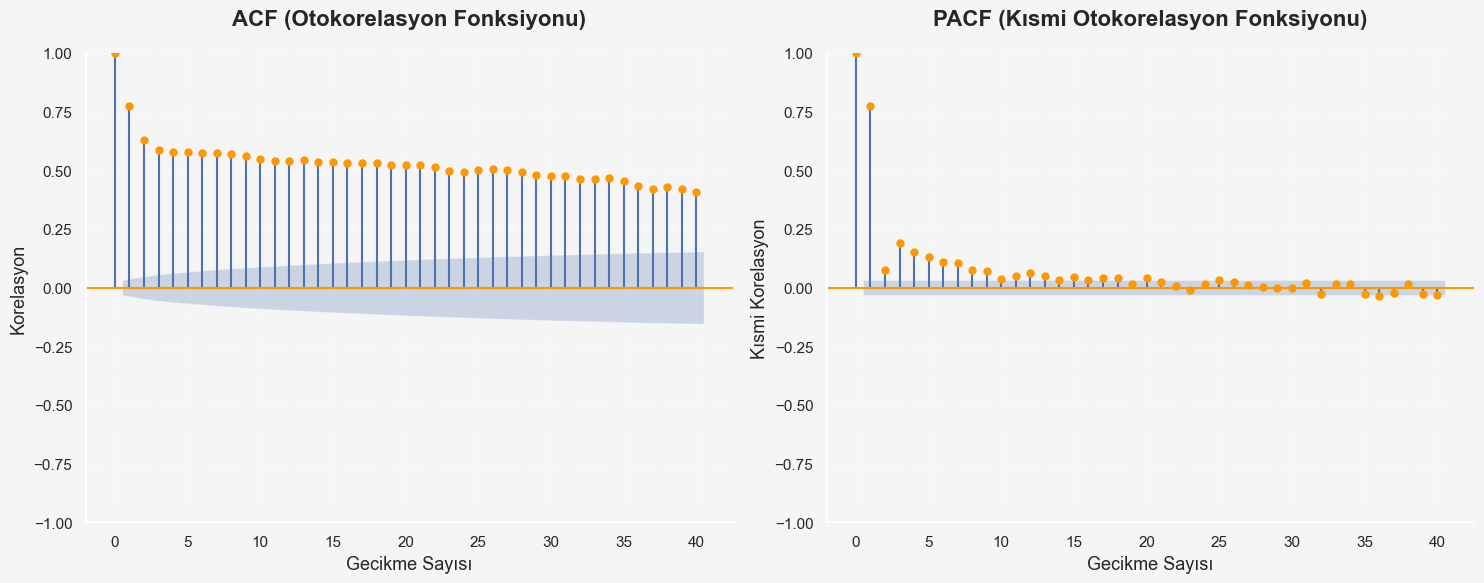

In [40]:
sns.set_theme(style="darkgrid")
colors = ['#007acc', '#ff9800']   

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#f5f5f5')

 
plot_acf(data['Temp'], lags=40, ax=ax1, color=colors[1], alpha=0.05)
ax1.set_title('ACF (Otokorelasyon Fonksiyonu)', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Gecikme Sayısı', fontsize=13)
ax1.set_ylabel('Korelasyon', fontsize=13)
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax1.set_facecolor("#f5f5f5")

 
plot_pacf(data['Temp'], lags=40, ax=ax2, method='ywm', color=colors[1], alpha=0.05)
ax2.set_title('PACF (Kısmi Otokorelasyon Fonksiyonu)', fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Gecikme Sayısı', fontsize=13)
ax2.set_ylabel('Kısmi Korelasyon', fontsize=13)
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax2.set_facecolor("#f5f5f5")

 
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=11)
    
plt.tight_layout()
plt.show()

In [42]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Modeli oluştur
model = ARIMA(data['Temp'], order=(1, 0, 0))

# Modeli eğit
model_fit = model.fit()

# Model özetini yazdır
print(model_fit.summary())


c:\Users\İlyas\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\İlyas\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\İlyas\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   Temp   No. Observations:                 3650
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -8629.862
Date:                Mon, 13 Oct 2025   AIC                          17265.725
Time:                        00:08:26   BIC                          17284.332
Sample:                             0   HQIC                         17272.352
                               - 3650                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.1887      0.191     58.603      0.000      10.814      11.563
ar.L1          0.7752      0.010     78.203      0.000       0.756       0.795
sigma2         6.6229      0.145     45.784      0.0

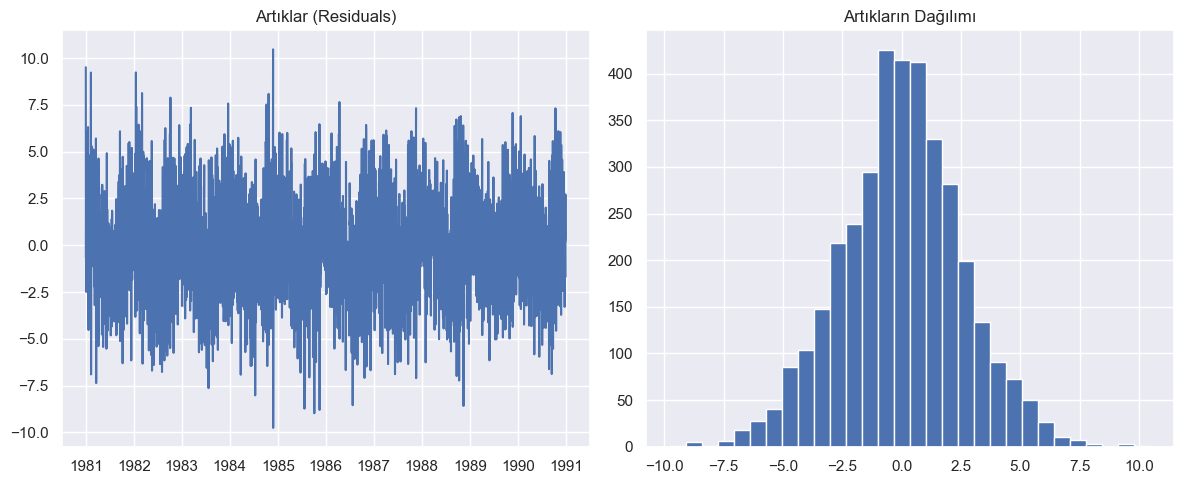

Artıkların ortalaması: -0.0020681523500420606


In [ ]:
residuals = model_fit.resid
 
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(residuals)
plt.title("Artıklar (Residuals)")

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30)
plt.title("Artıkların Dağılımı")
plt.tight_layout()
plt.show()
 
print("Artıkların ortalaması:", residuals.mean())


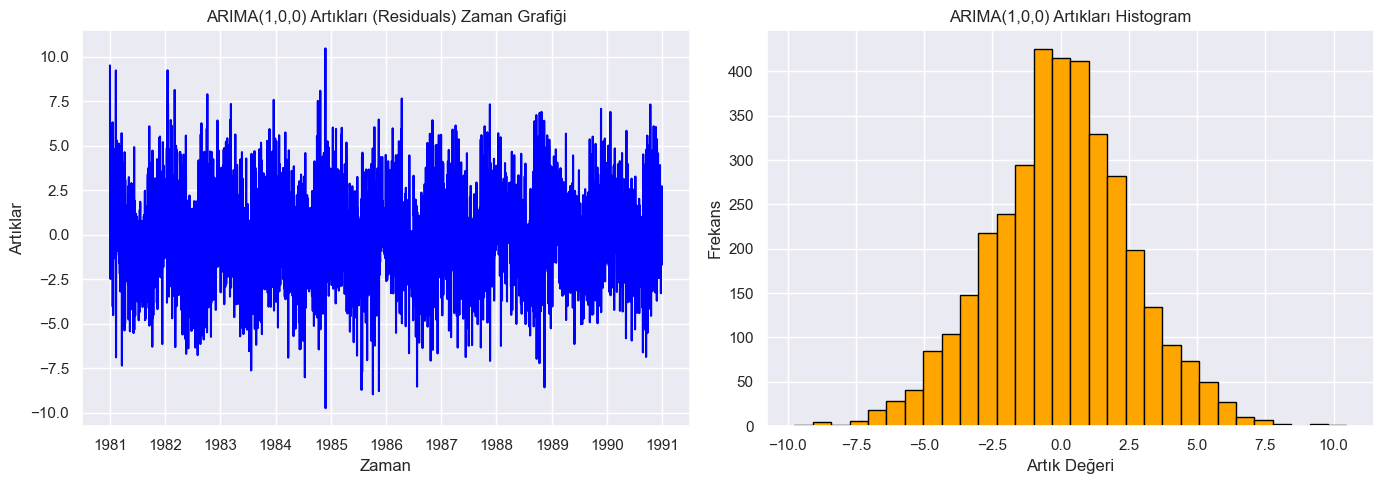

Artıkların ortalaması: -0.0020681523500420606


In [50]:
residuals = model_fit.resid

plt.figure(figsize=(14,5))
 
plt.subplot(1,2,1)
plt.plot(residuals, color='blue')
plt.title("ARIMA(1,0,0) Artıkları (Residuals) Zaman Grafiği")
plt.xlabel("Zaman")
plt.ylabel("Artıklar")
 
plt.subplot(1,2,2)
plt.hist(residuals, bins=30, color='orange', edgecolor='black')
plt.title("ARIMA(1,0,0) Artıkları Histogram")
plt.xlabel("Artık Değeri")
plt.ylabel("Frekans")

plt.tight_layout()
plt.show()
 
print("Artıkların ortalaması:", residuals.mean())
